In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [12]:
df = pd.read_csv('embedded_system_network_security_dataset.csv')

print(df.head())
print(df.info())
print(df.isnull().sum())

   packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
0     0.405154            0.620362     62569       443         0.857143   
1     0.527559            0.741288     59382       443         0.785714   
2     0.226199            0.485116     65484        80         0.285714   
3     0.573372            0.450965     51707        53         0.142857   
4     0.651396            0.888740     26915        53         0.714286   

   mean_packet_size  spectral_entropy  frequency_band_energy  label  \
0               0.0          0.834066               0.534891    0.0   
1               0.0          0.147196               0.990757    0.0   
2               0.0          0.855192               0.031781    0.0   
3               0.0          0.153220               0.169958    0.0   
4               0.0          0.923916               0.552053    0.0   

   protocol_type_TCP  protocol_type_UDP  src_ip_192.168.1.2  \
0              False               True                True

In [13]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [14]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [15]:
X = df.drop(columns=['label'])
y = df['label']

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # adjust based on dataset
    random_state=42
)

In [18]:
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})
print(df['anomaly'].value_counts())

anomaly
0    950
1     50
Name: count, dtype: int64


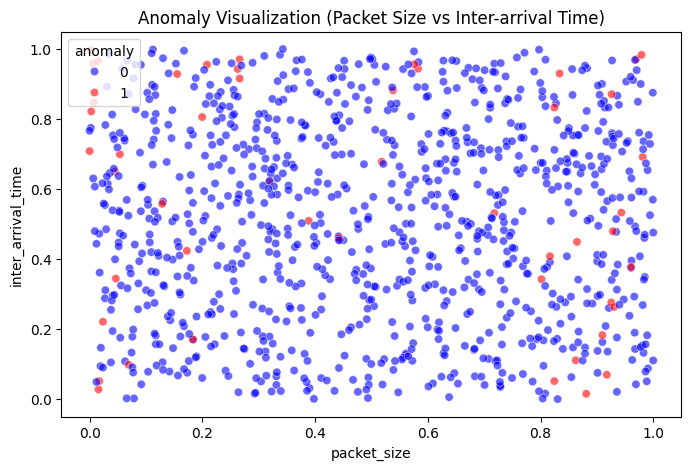

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['packet_size'],
    y=df['inter_arrival_time'],
    hue=df['anomaly'],
    palette={0: 'blue', 1: 'red'},
    alpha=0.6
)
plt.title("Anomaly Visualization (Packet Size vs Inter-arrival Time)")
plt.show()
